In [ ]:
#Import Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Read dataset
df=pd.read_csv("diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
# Replace 0 values in 'x', 'y', 'z' with NaN
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)

# Check for missing values after replacing 0s
display(df.isnull().sum())

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,8
y,7


In [ ]:
# Impute missing values (NaNs) in 'x', 'y', 'z' with the median of their respective columns
for column in ['x', 'y', 'z']:
    df[column].fillna(df[column].median(), inplace=True)

# Verify that there are no more missing values
display(df.isnull().sum())

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [ ]:
# Drop the 'Unnamed: 0' column as it's typically an index column and not needed for analysis.
df = df.drop('Unnamed: 0', axis=1)

# Check Duplication
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53794 non-null  float64
 1   cut      53794 non-null  object 
 2   color    53794 non-null  object 
 3   clarity  53794 non-null  object 
 4   depth    53794 non-null  float64
 5   table    53794 non-null  float64
 6   price    53794 non-null  int64  
 7   x        53794 non-null  float64
 8   y        53794 non-null  float64
 9   z        53794 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


In [ ]:
print("Available columns in your DataFrame:")
display(df.columns)

Available columns in your DataFrame:


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
# Display descriptive statistics for numerical features
df.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731956,5.735290,3.539960
std,0.47339,1.429909,2.233679,3988.114460,1.118786,1.139601,0.701893
min,0.20000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


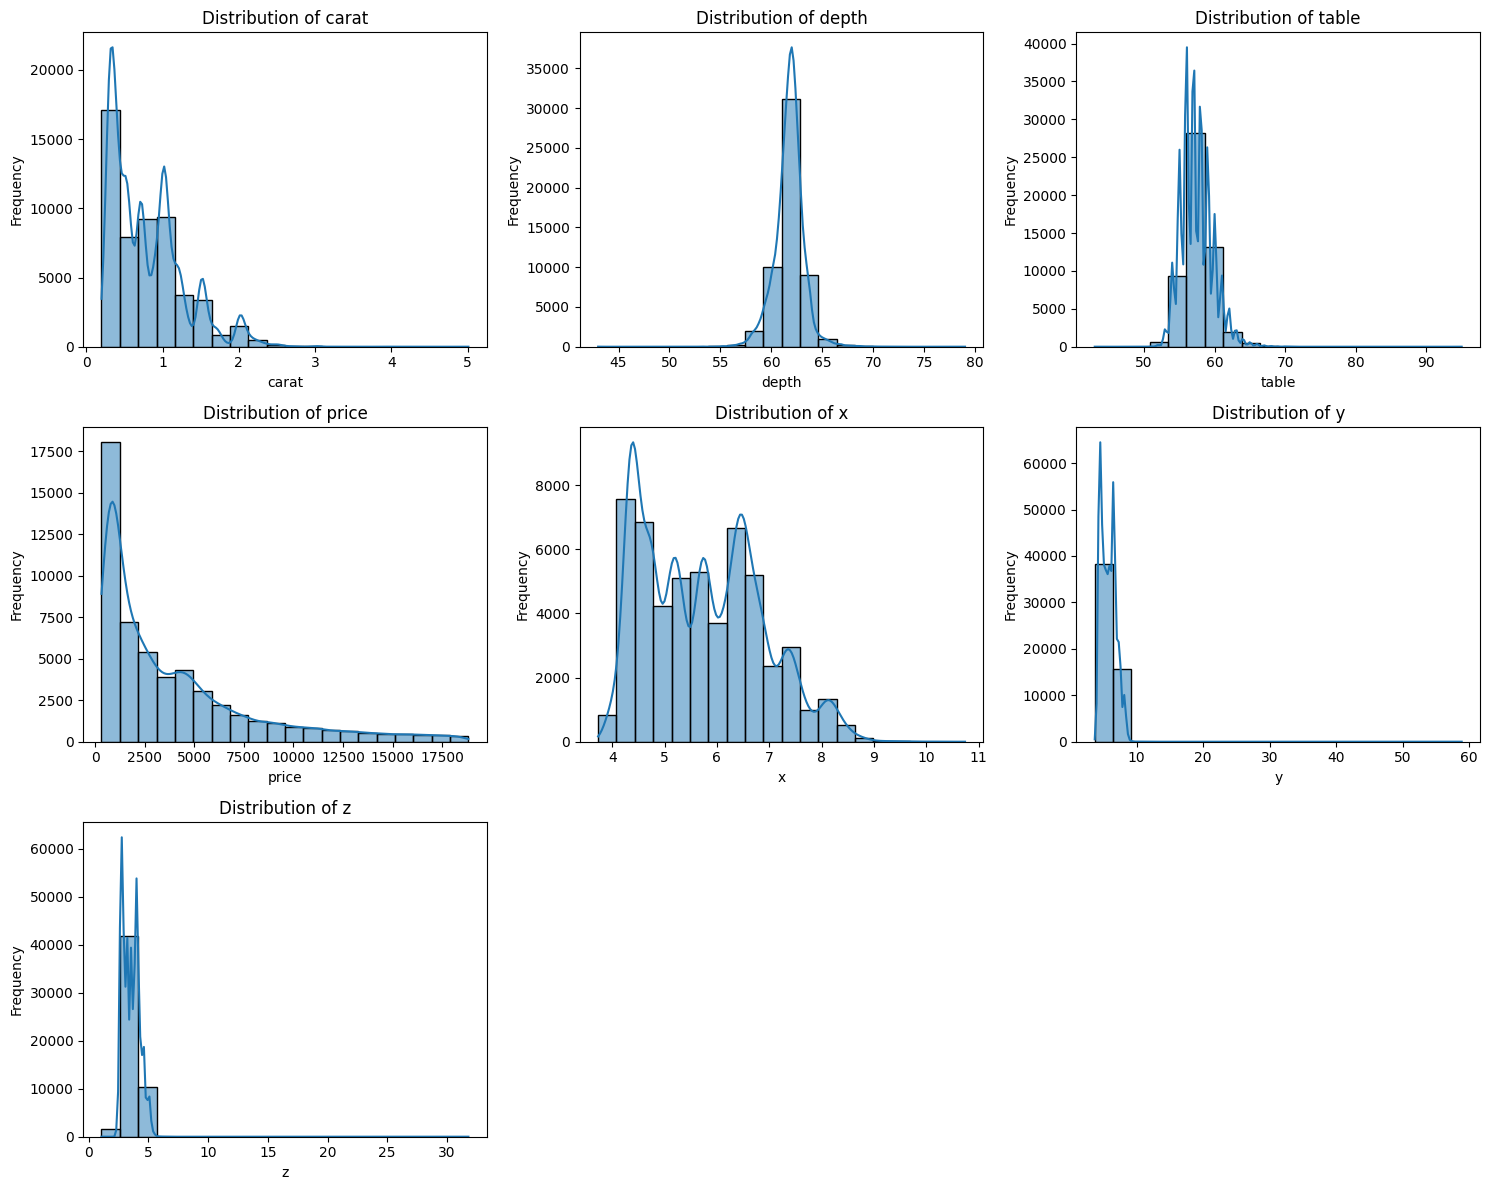

In [ ]:
# Visualize distributions of numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(15, 12)) # Adjust figure size for better visibility
for i, feature in enumerate(numerical_features):
    plt.subplot(round(len(numerical_features)/3)+1, 3, i + 1) # Arrange plots dynamically
    sns.histplot(data=df[feature], bins=20, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

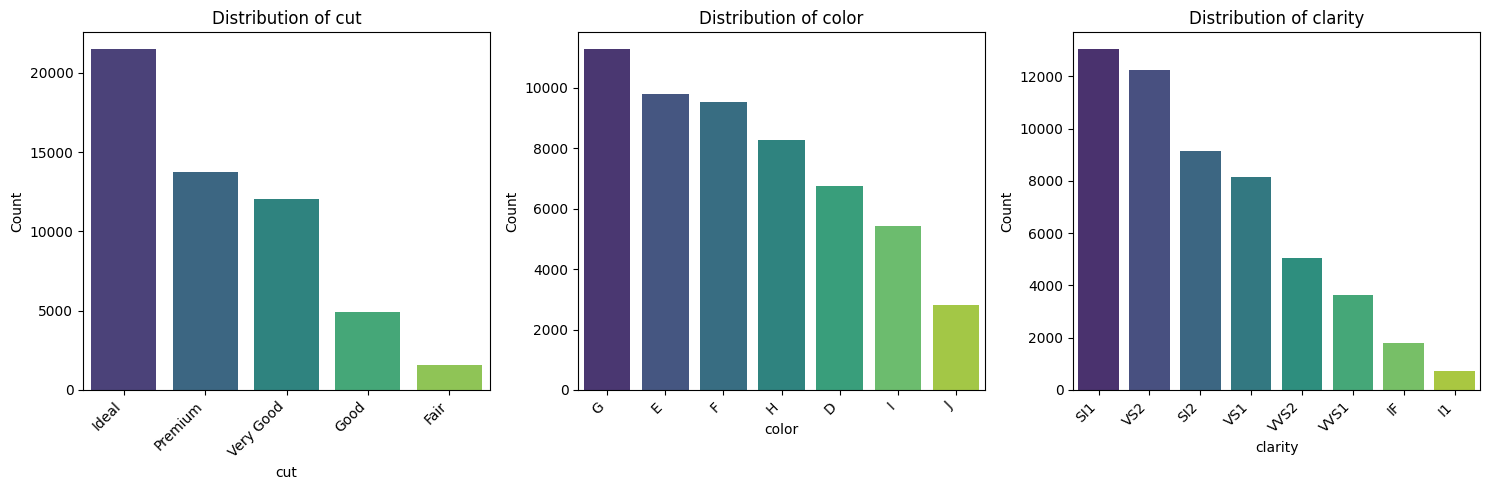

In [ ]:
# Visualize count plots for categorical features: cut, color, clarity
categorical_features = ['cut', 'color', 'clarity']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(categorical_features):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=feature, data=df, palette='viridis', order=df[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Feature Engineering and Preprocessing

In [ ]:
print(categorical_features)

['cut', 'color', 'clarity']


In [ ]:
from sklearn.preprocessing import StandardScaler

# Define numerical features to scale (excluding the target 'price' if it's numerical)
numerical_features_to_scale = ['carat', 'depth', 'table', 'x', 'y', 'z']

scaler = StandardScaler()
df[numerical_features_to_scale] = scaler.fit_transform(df[numerical_features_to_scale])

print("DataFrame head after scaling numerical features:")
display(df.head())

DataFrame head after scaling numerical features:


,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,-1.199402,-0.173495,-1.100486,326,-1.592774,-1.540282,-1.581397,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,-1.241651,-1.362393,1.585691,326,-1.646404,-1.663133,-1.752365,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,-1.199402,-3.390512,3.376475,327,-1.503390,-1.461306,-1.752365,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,-1.072656,0.455922,0.242603,334,-1.369315,-1.320905,-1.296450,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,-1.030407,1.085338,0.242603,335,-1.244178,-1.215604,-1.125482,True,False,False,...,False,False,True,False,False,True,False,False,False,False


In [ ]:
### Model Training for Price Prediction (Regression Task)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (43035, 23)
X_test shape: (10759, 23)
y_train shape: (43035,)
y_test shape: (10759,)


In [ ]:
# Train and evaluate a Linear Regression model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Model Performance:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lr):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred_lr):.2f}")

Linear Regression Model Performance:
Mean Squared Error: 1287381.04
R-squared: 0.92


In [ ]:
# Train  a RandomForestRegressor model
# اي هون زادت النسبة اذا شفتو
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandomForestRegressor Model Performance:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rf):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred_rf):.2f}")


RandomForestRegressor Model Performance:
Mean Squared Error: 349636.72
R-squared: 0.98


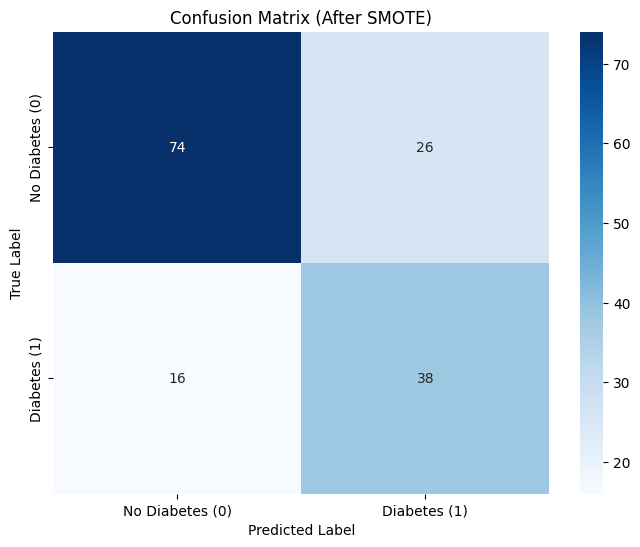

In [ ]:
### Model Comparison and Visualization